# **SES (EXPONENTIAL SMOOTHING)**

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv('/Users/pawan/Developer/Academics/5TH_SEM/Time Series/practical code/synthetic_sales.csv')
df

,Date,Sales
0,2018-01-01,202.483571
1,2018-02-01,209.308678
2,2018-03-01,220.558951
3,2018-04-01,227.615149
4,2018-05-01,216.149741
5,2018-06-01,208.829315
6,2018-07-01,207.896064
7,2018-08-01,193.837174
8,2018-09-01,180.332120
9,2018-10-01,182.712800


In [7]:
# --- 2. Apply Moving Averages ---
# 3-Point Moving Average: Averages the current and previous 2 points (if centered=False)
df['MA_3'] = df['Sales'].rolling(window=3).mean()

# 5-Point Moving Average: Averages the current and previous 4 points
df['MA_5'] = df['Sales'].rolling(window=5).mean()

# --- 3. Apply Simple Exponential Smoothing (SES) ---
# SES Formula: y_t = alpha * x_t + (1 - alpha) * y_{t-1}
# alpha = 0.3 implies we give 30% weight to the current observation and 70% to history.
df['SES_0.3'] = df['Sales'].ewm(alpha=0.3, adjust=False).mean()

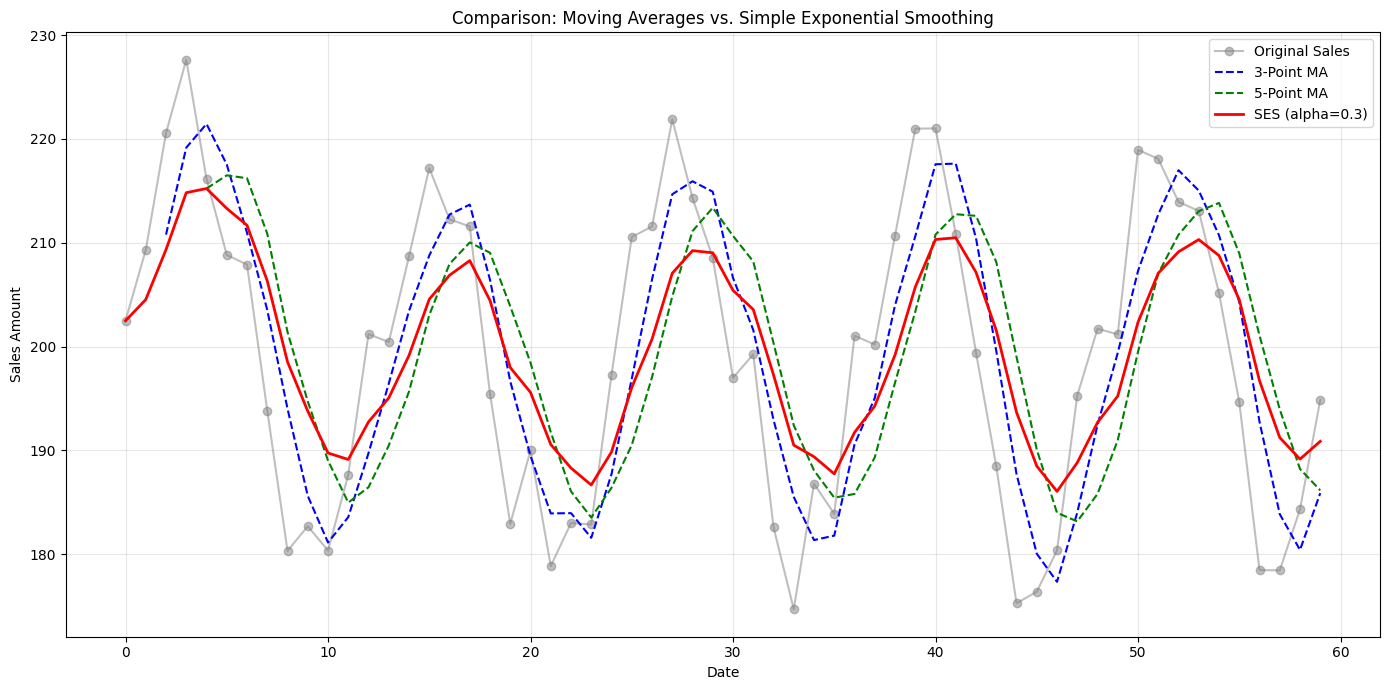

In [8]:
# --- 4. Plotting the Comparison ---
plt.figure(figsize=(14, 7))

# Original Data
plt.plot(df.index, df['Sales'], label='Original Sales', color='gray', alpha=0.5, marker='o')

# Moving Averages
plt.plot(df.index, df['MA_3'], label='3-Point MA', color='blue', linestyle='--')
plt.plot(df.index, df['MA_5'], label='5-Point MA', color='green', linestyle='--')

# Exponential Smoothing
plt.plot(df.index, df['SES_0.3'], label='SES (alpha=0.3)', color='red', linewidth=2)

plt.title('Comparison: Moving Averages vs. Simple Exponential Smoothing')
plt.xlabel('Date')
plt.ylabel('Sales Amount')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()